# electrification cement NPV simulation

Run the electrification cement Monte Carlo simulation and visualize the resulting NPV distribution.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)


In [2]:
TECHNOLOGY = 'electrification'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,electricity_consumption_mwh_per_t,...,annual_variable_opex_eur,annual_fuel_cost_eur,annual_electricity_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_t,npv_eur_per_t,npv_million_eur_per_t,coal_price_eur_per_mwh_th
0,0,electrification,absolute,not_applicable,1000000.0,208.698817,25.157297,9.410140,0.0,0.993393,...,9.410140e+06,0.0,2.042967e+08,3.032936e+07,-1.191935e+08,-1.481063e+09,25000000.0,-59.242507,-0.000059,11.552349
1,1,electrification,absolute,not_applicable,1000000.0,170.893615,17.306545,8.881603,0.0,0.913259,...,8.881603e+06,0.0,2.126920e+08,3.207678e+07,-1.209569e+08,-1.462082e+09,25000000.0,-58.483271,-0.000058,12.046282
2,2,electrification,absolute,not_applicable,1000000.0,225.287484,19.895200,8.951326,0.0,0.927756,...,8.951326e+06,0.0,1.837474e+08,3.553061e+07,-9.812457e+07,-1.272745e+09,25000000.0,-50.909811,-0.000051,13.635991
3,3,electrification,absolute,not_applicable,1000000.0,196.719996,23.150093,6.219574,0.0,0.917870,...,6.219574e+06,0.0,1.964091e+08,3.461011e+07,-1.103889e+08,-1.375097e+09,25000000.0,-55.003882,-0.000055,12.310167
4,4,electrification,absolute,not_applicable,1000000.0,252.930094,24.463389,9.053570,0.0,0.912908,...,9.053570e+06,0.0,1.751118e+08,2.851207e+07,-8.714079e+07,-1.183138e+09,25000000.0,-47.325539,-0.000047,14.021164


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_t = results["npv_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/t"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/t
count,100000.000000,100000.000000
mean,-1115.124266,-44.604971
std,372.921702,14.916868
min,-2059.431223,-82.377249
5%,-1681.465829,-67.258633
50%,-1137.567444,-45.502698
95%,-461.954651,-18.478186
max,30.072229,1.202889


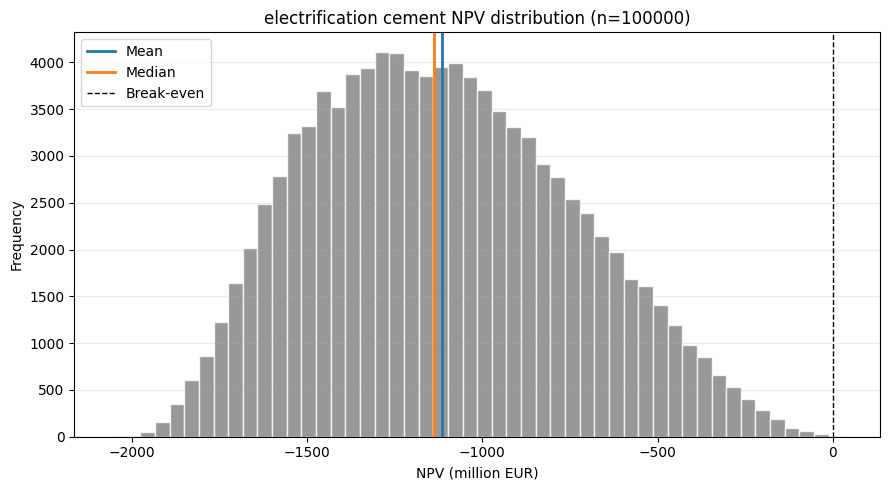

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrification cement NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


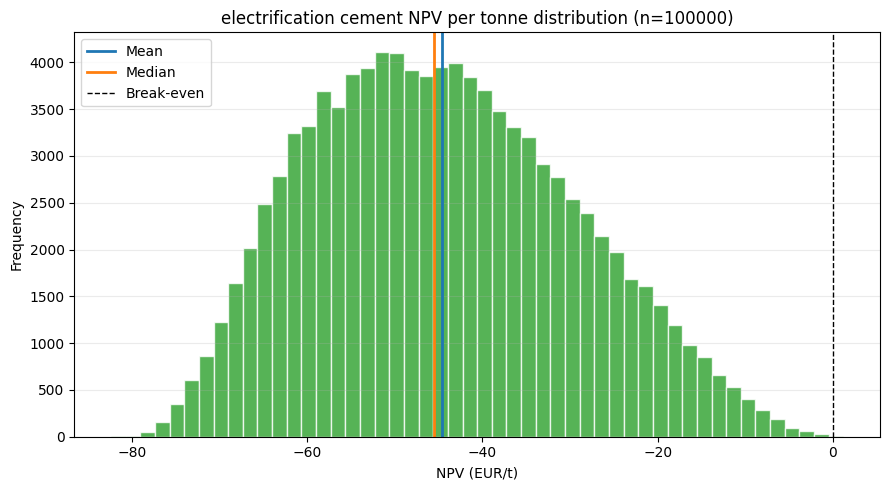

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrification cement NPV per tonne distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/t)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           19.986132
annual_variable_opex_eur         7.802609
annual_fuel_cost_eur             0.000000
annual_electricity_cost_eur    174.552662
annual_emissions_cost_eur       32.011967
annual_net_cash_flow_eur       -84.353370
Name: Mean annual value, million EUR, dtype: float64